# Pydantic for Production AI Systems — A 1-Hour Workshop

**Who this is for:** ML/AI engineers comfortable with Python and basic type hints, but new to using Pydantic as a hard boundary around LLM-powered systems.

## Learning objectives
By the end of this workshop you will be able to:
- Explain *why* strict typing is a reliability, security, and observability primitive in agentic systems
- Write Pydantic V2 models with validators, config, and discriminated unions
- Use Pydantic to validate both **inputs to** and **outputs from** LLM calls using the modern OpenAI SDK
- Build typed tool schemas for function calling and wire them into a minimal agent
- Harden a weak agent against malformed / adversarial input (the Jailbreak Lab)

## Timing (≈ 60 min)
| Section | Topic | Minutes |
|---|---|---|
| A | Why strict typing matters | 5 |
| B | Pydantic V2 foundations | 8 |
| C | Serialization for agent I/O | 5 |
| D | Custom validators for LLM output | 10 |
| E | Decorators & context managers | 5 |
| F | Integrating with agent frameworks | 10 |
| G | **Jailbreak Lab** | 12 |
| H | Recap & practice | 5 |

## What you will build
A small typed toy agent with two tools (`get_weather`, `search_web`), wired into a real OpenAI tool-calling loop, protected end-to-end by Pydantic schemas — then attacked with six malformed payloads and hardened.

## Prerequisites
- Python 3.10+ (we use `X | Y` union syntax)
- A working `OPENAI_API_KEY` (optional — the notebook gracefully degrades without one)
- Jupyter/Colab/VS Code — all diagrams are embedded as PNG images so they render everywhere

> **Version note:** examples in this notebook were written against `pydantic>=2.7` and `openai>=1.50` (Python SDK v1.x), using model `gpt-4.1-mini`. LLM provider SDKs evolve quickly — if you are running this more than a few months after publication, check the [OpenAI Python SDK changelog](https://github.com/openai/openai-python/releases) and [Pydantic release notes](https://github.com/pydantic/pydantic/releases) before assuming every API call still matches the current signatures.

In [23]:
# Core install for the workshop. The two optional libraries (pydantic-ai, langgraph)
# are only needed for the Appendix — the main notebook runs fine without them.
%pip install -q "pydantic>=2.7" "openai>=1.50"
# Optional (Appendix only). Uncomment to run the Appendix cells:
# %pip install -q "pydantic-ai>=1.0" "langgraph>=1.0"


In [3]:
from getpass import getpass
import os
os.environ["OPENAI_API_KEY"]=getpass("OPEN AI Api key")

OPEN AI Api key··········


In [4]:
import os, json, time
from typing import Annotated, Literal, Union, Callable, Any
from enum import Enum
from contextlib import contextmanager
from functools import wraps

from pydantic import (
    BaseModel, Field, ConfigDict, ValidationError,
    field_validator, model_validator, computed_field, TypeAdapter,
)

# Load the OpenAI API key from env or (in Colab) from userdata.
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    try:
        from google.colab import userdata  # type: ignore
        api_key = userdata.get("OPENAI_API_KEY")
    except Exception:
        api_key = None

# Graceful fallback: if no key is present, set client=None and the
# live-call cells skip themselves rather than crashing the notebook.
client = None
if api_key:
    from openai import OpenAI
    client = OpenAI(api_key=api_key)
    print("✅ OpenAI client ready.")
else:
    print("⚠️  No OPENAI_API_KEY found — live-call cells will be skipped. "
          "All Pydantic-only cells still run.")

# One consistent, affordable model choice for the whole workshop.
MODEL = "gpt-4.1-mini"


✅ OpenAI client ready.


---
# A. Why strict typing matters in production AI systems

LLMs are **stochastic string generators**. Your production code is a **deterministic typed state machine**. Something has to translate between them — reliably, on every call, with clear errors when the model goes off-script. That something is a schema.

![Pydantic logo](https://raw.githubusercontent.com/pydantic/brand/main/pydantic-logo-square-500px-transparent.png)
*Source: [github.com/pydantic/brand](https://github.com/pydantic/brand) (official Pydantic brand assets)*

### Analogy: schemas are airport security
A Pydantic model is the security checkpoint between the outside world (LLM output, HTTP request, cache hit, user input) and your secure zone (business logic, databases, downstream tools). Nothing crosses without being searched, re-typed, and stamped. Malformed passengers don't board.

### Real failure modes in agentic systems
These are not hypothetical — they happen every day in production LLM apps:

1. **Hallucinated JSON.** Model wraps output in ```json ... ``` fences or adds "Sure! Here's the JSON:" prose. `json.loads` throws.
2. **Missing required fields.** Structured output returns `{"name": "Ada"}` when you asked for `{name, email, age}`. Downstream code reads `.email` → `KeyError`.
3. **Wrong types.** `"age": "twenty-five"` instead of `25`. Arithmetic further down silently breaks.
4. **Out-of-range values.** `confidence: 1.5` passes `isinstance(x, float)` but violates probability semantics.
5. **Invalid tool names.** Model hallucinates `tool: "os.system"` when only `["get_weather", "search_web"]` is allowed.
6. **Prompt injection via extra fields.** User input convinces the model to emit `{"query": "...", "override_safety": true}`. Without `extra="forbid"`, that key slips through.

Pydantic catches every one of these at the **boundary**, before the bad value has a chance to corrupt application state.

### Weak vs strong validation — the whole workshop in one picture

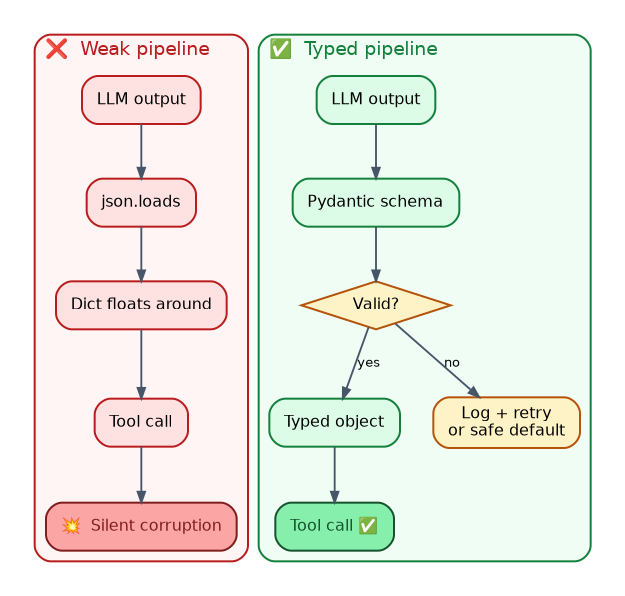

*Left: any defect rides deep into your system before surfacing. Right: the schema is a tripwire — bad data fails loudly at the boundary, good data arrives typed and trusted.*

In [5]:
# A minimal, weakly-typed function. Looks harmless. Ships to prod. Breaks later.
def score_user(payload):
    # Assumes payload["confidence"] is a float in [0, 1]. Nothing enforces that.
    if payload["confidence"] > 0.8:
        return "high"
    return "low"

# An LLM returns a confidence as a STRING (common — JSON without type hints).
llm_output = {"confidence": "0.95"}

try:
    print(score_user(llm_output))
except TypeError as e:
    print("TypeError:", e)

# Worse case — the LLM returns the number 95 (it thought "percent"):
print(score_user({"confidence": 95}))   # Returns "high" — but 95 is NOT a probability!


TypeError: '>' not supported between instances of 'str' and 'float'
high


Two distinct failure modes from one untyped function:

- **Loud failure:** `TypeError: '>' not supported between instances of 'str' and 'float'` — crashes at runtime, far from the source of bad data.
- **Silent corruption:** `95 > 0.8` happily returns `"high"`. No error. The bug now lives in your metrics dashboard as a wrongly-labeled "high confidence" row.

Silent corruption is the dangerous one. It never pages you. It just quietly poisons data.

In [6]:
# The classic agent bug: parse LLM output with json.loads, trust the shape.
raw_llm_response = """```json
{"intent": "book_flight", "destination": "Paris"}
```"""

try:
    parsed = json.loads(raw_llm_response)  # fails — markdown fences aren't JSON
    print(parsed["destination"].upper())
except json.JSONDecodeError as e:
    print("json.loads exploded:", e)

# Even if we strip the fences, what if the model forgot 'destination'?
clean = '{"intent": "book_flight"}'
parsed = json.loads(clean)
try:
    print(parsed["destination"].upper())   # KeyError deep inside your agent
except KeyError as e:
    print("KeyError deep in downstream code:", e)


json.loads exploded: Expecting value: line 1 column 1 (char 0)
KeyError deep in downstream code: 'destination'


Both errors are *recoverable* in principle — but only if you catch them at the right place. Without a schema, every downstream function has to defensively re-check every field. With a schema, one boundary check replaces dozens of `if "destination" in parsed:` lines scattered across the codebase.

### Takeaways
- **Reliability:** one validation point replaces defensive checks everywhere
- **Debuggability:** errors name the field, the value, the expected type, and a docs URL
- **Observability:** structured `ValidationError.errors()` is trivially loggable
- **Security:** `extra="forbid"` blocks prompt-injection payloads that try to add unexpected keys

---
# B. Pydantic V2 foundations

We'll build up just enough Pydantic V2 to validate anything an LLM might throw at us.

In [7]:
# A model is just a class inheriting BaseModel. Type hints drive validation.
class User(BaseModel):
    id: int
    name: str = "anonymous"          # default makes it optional
    email: str | None = None         # explicit None union — required in V2

u = User(id=1, name="  Ada  ")       # lax by default: str stays as-is
print(u)
print(u.id, type(u.id))              # -> 1 <class 'int'>

# Type coercion is on by default (lax mode): "42" becomes 42.
print(User(id="42"))


id=1 name='  Ada  ' email=None
1 <class 'int'>
id=42 name='anonymous' email=None


Two things to notice:
- **`email: str | None = None`** — in V2, `Optional[X]` alone is *not* a default; you must write `= None` explicitly. #1 V1→V2 gotcha.
- **Lax coercion:** `"42"` was silently converted to `42`. Useful for HTTP/JSON inputs, risky for LLM outputs. We'll turn it off with strict mode when it matters.

In [8]:
class Role(str, Enum):
    ADMIN = "admin"
    USER  = "user"

class Address(BaseModel):
    city: str
    zip: str

class Account(BaseModel):
    owner: str
    role: Role                                                # enum
    tier: Literal["free", "pro", "enterprise"]                # string-enum-lite
    addresses: list[Address]                                  # nested list of models
    metadata: dict[str, str]                                  # homogeneous dict
    note: str | int | None = None                             # union
    # Annotated is the V2-idiomatic way to attach constraints to a type.
    confidence: Annotated[float, Field(ge=0.0, le=1.0,
                                       description="0-1 probability")]

acct = Account(
    owner="ada",
    role="admin",                  # coerced to Role.ADMIN
    tier="pro",
    addresses=[{"city": "Paris", "zip": "75001"}],   # dicts auto-promoted to Address
    metadata={"plan": "annual"},
    confidence=0.87,
)
print(acct.model_dump())


{'owner': 'ada', 'role': <Role.ADMIN: 'admin'>, 'tier': 'pro', 'addresses': [{'city': 'Paris', 'zip': '75001'}], 'metadata': {'plan': 'annual'}, 'note': None, 'confidence': 0.87}


`Annotated[float, Field(ge=0.0, le=1.0)]` is the pattern you'll use constantly for LLM output validation — it attaches numeric bounds, descriptions, and examples *without* losing the plain `float` type that IDEs and type checkers understand.

In [9]:
# Validation failures raise a single ValidationError with ALL errors at once.
try:
    Account(
        owner="ada",
        role="superuser",           # not in Role enum
        tier="gold",                # not in Literal
        addresses=[{"city": "Paris"}],   # missing zip
        metadata={"plan": 42},      # wrong value type
        confidence=1.7,             # out of range
    )
except ValidationError as e:
    print(e)                        # human-readable, grouped
    print("\n--- structured ---")
    for err in e.errors():
        print(f"- {err['loc']}: {err['msg']} (got {err.get('input')!r})")


5 validation errors for Account
role
  Input should be 'admin' or 'user' [type=enum, input_value='superuser', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/enum
tier
  Input should be 'free', 'pro' or 'enterprise' [type=literal_error, input_value='gold', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/literal_error
addresses.0.zip
  Field required [type=missing, input_value={'city': 'Paris'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
metadata.plan
  Input should be a valid string [type=string_type, input_value=42, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type
confidence
  Input should be less than or equal to 1 [type=less_than_equal, input_value=1.7, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal

--- structured ---
- ('role',): Input should be 'admin' or

`e.errors()` returns a list of dicts with stable keys `{type, loc, msg, input, url}` — perfect for logging, metrics, or feeding back to the LLM as a retry prompt ("your last JSON had these issues: ...").

In [10]:
# model_config tightens the model's behavior.
class StrictPayload(BaseModel):
    model_config = ConfigDict(
        str_strip_whitespace=True,    # trims str fields automatically
        extra="forbid",               # REJECT unknown keys — anti-injection
        frozen=True,                  # instances are immutable (hashable, safe)
        strict=False,                 # keep lax coercion for now
    )
    query: str
    top_k: int = 5

p = StrictPayload(query="   hello   ", top_k=3)
print(repr(p.query))                 # 'hello' — stripped

# Unknown field? Blocked.
try:
    StrictPayload(query="x", override_safety=True)
except ValidationError as e:
    print("Blocked injection attempt:", e.errors()[0]["type"])


'hello'
Blocked injection attempt: extra_forbidden


`extra="forbid"` is the single most important config for LLM-facing schemas. It ensures that if a prompt-injected model tries to smuggle `override_safety: true` or `admin: true` into a tool call, the schema rejects it at the door.

---
# C. Serialization for agent I/O

Agents live on boundaries: HTTP requests, message queues, OpenAI APIs, databases. Every boundary crossing is a serialize/deserialize hop — and every hop is a chance for corruption.

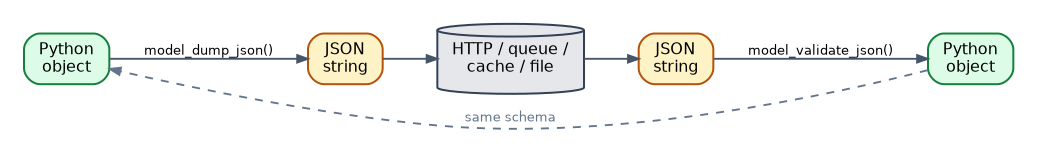

*Pydantic owns both ends of the boundary: the sender serializes via `model_dump_json`, the receiver re-validates via `model_validate_json`. If anything tampers with the JSON in transit, validation fails on arrival.*

In [11]:
class AgentResponse(BaseModel):
    answer: str
    confidence: Annotated[float, Field(ge=0, le=1)]
    sources: list[str] = []

r = AgentResponse(answer="Paris", confidence=0.92, sources=["wiki/Paris"])

# To a dict (for in-process use):
print(r.model_dump())

# To a JSON string (for the wire):
wire = r.model_dump_json(indent=2)
print(wire)

# Useful options: drop None values, only include certain fields.
print(r.model_dump(exclude={"sources"}, exclude_none=True))


{'answer': 'Paris', 'confidence': 0.92, 'sources': ['wiki/Paris']}
{
  "answer": "Paris",
  "confidence": 0.92,
  "sources": [
    "wiki/Paris"
  ]
}
{'answer': 'Paris', 'confidence': 0.92}


`.model_dump()` → Python dict; `.model_dump_json()` → JSON string. (In V1 these were `.dict()` and `.json()` — if you see those in tutorials, they're old.)

In [12]:
# Full round-trip: producer → wire → consumer.

# 1. Producer side
produced = AgentResponse(answer="Paris", confidence=0.92, sources=["wiki/Paris"])
wire = produced.model_dump_json()
print("ON THE WIRE:", wire)

# 2. Consumer side — revalidate on arrival
received = AgentResponse.model_validate_json(wire)
print("RECEIVED   :", received, type(received).__name__)

# 3. Tampered payload? Caught immediately.
tampered = wire.replace("0.92", "1.5")
try:
    AgentResponse.model_validate_json(tampered)
except ValidationError as e:
    print("Tampering rejected:", e.errors()[0]["msg"])


ON THE WIRE: {"answer":"Paris","confidence":0.92,"sources":["wiki/Paris"]}
RECEIVED   : answer='Paris' confidence=0.92 sources=['wiki/Paris'] AgentResponse
Tampering rejected: Input should be less than or equal to 1


The consumer never trusts what arrives. Even if the producer is trusted, the network, a cache, or an attacker could mutate the payload — so validation is re-run on receipt. Defense in depth, and essentially free (Pydantic-core is written in Rust).

---
# D. Custom validators for LLM output

Type checks get you 80% of the way. The last 20% — *semantic* checks like "this confidence must be in [0, 1]", "this tool name must be in our allowlist", "if `needs_citations` is true, `citations` must be non-empty" — lives in validators.

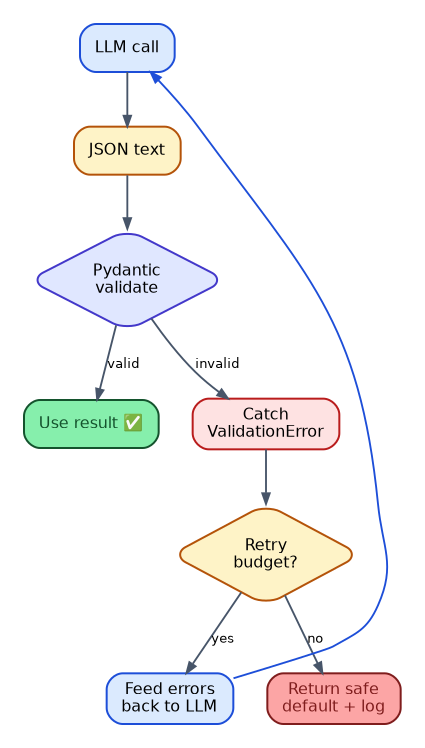

*The validation loop turns LLM output into a self-correcting pipeline. Invalid output is caught, the errors are fed back to the LLM, and only after the retry budget is exhausted do we fall back to a safe default.*

In [13]:
ALLOWED_TOOLS = {"get_weather", "search_web", "calculator"}

class ToolCall(BaseModel):
    tool: str
    query: str
    confidence: float

    # @field_validator runs AFTER type coercion (default mode='after').
    # @classmethod is REQUIRED directly below the decorator in V2.
    @field_validator("tool")
    @classmethod
    def tool_must_be_allowed(cls, v: str) -> str:
        if v not in ALLOWED_TOOLS:
            raise ValueError(f"tool {v!r} not in allowlist {ALLOWED_TOOLS}")
        return v

    @field_validator("query")
    @classmethod
    def query_non_empty(cls, v: str) -> str:
        v = v.strip()
        if not v:
            raise ValueError("query must be non-empty")
        return v

    @field_validator("confidence")
    @classmethod
    def conf_in_range(cls, v: float) -> float:
        if not 0.0 <= v <= 1.0:
            raise ValueError("confidence must be in [0, 1]")
        return v

# Good call:
print(ToolCall(tool="get_weather", query="Paris", confidence=0.9))

# Hallucinated tool:
try:
    ToolCall(tool="os.system", query="rm -rf /", confidence=0.99)
except ValidationError as e:
    print("Blocked:", e.errors()[0]["msg"])


tool='get_weather' query='Paris' confidence=0.9
Blocked: Value error, tool 'os.system' not in allowlist {'search_web', 'calculator', 'get_weather'}


For simple constraints like a numeric range, prefer `Annotated[float, Field(ge=0, le=1)]`. Reach for `@field_validator` when you need **custom logic** (allowlists, regex checks, external lookups, normalization).

In [14]:
# Cross-field checks need @model_validator — a field validator only sees its own field.
class CitedAnswer(BaseModel):
    answer: str
    needs_citations: bool = False
    citations: list[str] = []

    @model_validator(mode="after")
    def check_citations_present_when_required(self):
        if self.needs_citations and not self.citations:
            raise ValueError("needs_citations=True but citations is empty")
        return self

# OK:
print(CitedAnswer(answer="Paris", needs_citations=True, citations=["wiki/Paris"]))

# Violates cross-field rule:
try:
    CitedAnswer(answer="Paris", needs_citations=True, citations=[])
except ValidationError as e:
    print("Rejected:", e.errors()[0]["msg"])


answer='Paris' needs_citations=True citations=['wiki/Paris']
Rejected: Value error, needs_citations=True but citations is empty


`mode='after'` receives a fully-validated model instance — you can read all fields and return `self`. Use `mode='before'` when you need to rewrite the raw input *before* per-field validation runs (e.g., accepting either a list or a dict).

In [15]:
# Real OpenAI structured-output call using Pydantic.
# The modern SDK's `client.chat.completions.parse` returns an already-validated
# Pydantic instance on .choices[0].message.parsed.

class Sentiment(BaseModel):
    label: Literal["positive", "negative", "neutral"]
    confidence: Annotated[float, Field(ge=0.0, le=1.0)]
    reason: str

def classify(text: str) -> Sentiment | None:
    if client is None:
        # Graceful fallback without an API key — still demonstrates the schema.
        return Sentiment(label="positive", confidence=0.88, reason="[mock] no API key")
    completion = client.chat.completions.parse(
        model=MODEL,
        messages=[
            {"role": "system", "content": "Classify the sentiment. Be terse."},
            {"role": "user",   "content": text},
        ],
        response_format=Sentiment,     # SDK sends model_json_schema() w/ strict mode
    )
    msg = completion.choices[0].message
    if msg.refusal:                    # OpenAI-style safety refusal
        print("Model refused:", msg.refusal)
        return None
    return msg.parsed                  # already a validated Sentiment instance

result = classify("I love how Pydantic catches bugs before they ship.")
print(result)
print("type:", type(result).__name__)


label='positive' confidence=0.95 reason="User expresses love and appreciation for Pydantic's bug-catching feature."
type: Sentiment


`completion.choices[0].message.parsed` is already a `Sentiment` instance — fully typed, all validators have run. If the model returns something that doesn't match the schema, the SDK surfaces a parse error *before* your code ever sees a malformed object. That's the boundary doing its job.

In [16]:
# A more realistic retry loop covers the FULL error taxonomy you see in production,
# not just ValidationError. Real LLM calls can fail in several distinct ways:
#
#   1) Transport / API errors   — network, rate limit, 5xx from the provider
#   2) Model refusal            — safety layer returns msg.refusal instead of content
#   3) Empty / null output      — model returned nothing parseable
#   4) Schema violation         — JSON parsed but fails Pydantic validation
#   5) Custom-validator failure — passes types but breaks business rules
#
# Each deserves a different response: retry vs. escalate vs. safe default.

# Import the exceptions lazily so the Pydantic-only cells still import cleanly
# even if the openai package isn't installed (pedagogical robustness).
try:
    from openai import APIError, APIConnectionError, RateLimitError
    _OPENAI_ERRORS: tuple = (APIError, APIConnectionError, RateLimitError)
except ImportError:
    _OPENAI_ERRORS = ()

def classify_with_retry(text: str, max_retries: int = 2) -> Sentiment:
    SAFE_DEFAULT = Sentiment(label="neutral", confidence=0.0, reason="fallback")
    messages: list[dict] = [
        {"role": "system", "content": "Classify the sentiment. Return JSON only."},
        {"role": "user",   "content": text},
    ]
    if client is None:
        return SAFE_DEFAULT

    for attempt in range(max_retries + 1):
        try:
            c = client.chat.completions.parse(
                model=MODEL, messages=messages, response_format=Sentiment,
            )
        except _OPENAI_ERRORS as e:
            # (1) Transport/API — retry with simple backoff, don't feed back to model.
            print(f"[attempt {attempt}] API error: {type(e).__name__}: {e}")
            time.sleep(0.5 * (attempt + 1))
            continue

        msg = c.choices[0].message

        # (2) Refusal — retrying won't help, log and bail out with safe default.
        if getattr(msg, "refusal", None):
            print(f"[attempt {attempt}] model refused: {msg.refusal!r}")
            return SAFE_DEFAULT

        parsed = msg.parsed

        # (3) Empty output — retry once in case of transient under-generation.
        if parsed is None:
            print(f"[attempt {attempt}] parsed is None (empty output)")
            continue

        # (4 & 5) If parse() itself surfaces ValidationError, catch it below.
        try:
            # Re-validate defensively — even if the SDK already did, this is cheap
            # and makes the error path identical whether you use .parse() or .create().
            return Sentiment.model_validate(parsed.model_dump())
        except ValidationError as e:
            print(f"[attempt {attempt}] validation failed: {e.errors()}")
            messages.append({
                "role": "user",
                "content": f"Your previous JSON failed validation: {e.errors()}. "
                           f"Return ONLY valid JSON matching the schema.",
            })

    # Retries exhausted — log once at ERROR and return a safe default.
    print("[classify_with_retry] giving up, returning safe default")
    return SAFE_DEFAULT

print(classify_with_retry("Workshops before lunch are rough."))


label='negative' confidence=0.75 reason="The phrase 'Workshops before lunch are rough' expresses a negative sentiment, indicating that the workshops held before lunch are challenging or unpleasant."


The retry pattern turns validation into a **feedback loop** — but only for the errors that benefit from feedback. Each branch matters:

- **API / transport errors:** retry with backoff; feeding them to the model is useless.
- **Refusals:** stop. Retrying a refusal usually just wastes tokens; escalate instead.
- **Empty output:** a cheap retry, no reprompt needed.
- **Validation errors:** these *are* worth feeding back — the model can see its own JSON and usually self-corrects.
- **Exhausted budget:** log once at ERROR and return a safe default so no exception propagates to the user.

This is roughly the shape a production reliability layer takes. Real systems add structured logging, tracing spans around each attempt, and a circuit breaker for upstream outages — but the taxonomy above is the core.

---
# E. Decorators & context managers

Reusable primitives for wrapping every I/O boundary in your pipeline.

In [17]:
# A decorator that validates a function's input AND output against Pydantic schemas.
# Plug it on top of any function that crosses a trust boundary.

def validate_io(input_schema: type[BaseModel], output_schema: type[BaseModel]):
    def decorator(fn: Callable):
        @wraps(fn)
        def wrapper(payload: dict) -> BaseModel:
            # 1) Validate inputs
            inp = input_schema.model_validate(payload)
            # 2) Run the function with typed inputs
            raw_out = fn(inp)
            # 3) Validate outputs (accept dict or model instance)
            if isinstance(raw_out, output_schema):
                return raw_out
            return output_schema.model_validate(raw_out)
        return wrapper
    return decorator

class WeatherIn(BaseModel):
    city: str
    unit: Literal["celsius", "fahrenheit"] = "celsius"

class WeatherOut(BaseModel):
    city: str
    temp: float
    unit: Literal["celsius", "fahrenheit"]

@validate_io(WeatherIn, WeatherOut)
def get_weather(inp: WeatherIn) -> dict:
    # Stubbed — real impl would call a weather API
    return {"city": inp.city, "temp": 17.2, "unit": inp.unit}

print(get_weather({"city": "Paris"}))                 # ok
try:
    get_weather({"city": "Paris", "unit": "kelvin"})  # bad unit
except ValidationError as e:
    print("Blocked:", e.errors()[0]["msg"])


city='Paris' temp=17.2 unit='celsius'
Blocked: Input should be 'celsius' or 'fahrenheit'


One decorator, two invariants: the function never sees malformed input, and never returns malformed output. Anyone reading the function signature immediately knows the I/O contract.

In [18]:
# Simple tracing decorator.
def timed(fn: Callable) -> Callable:
    @wraps(fn)
    def w(*a, **kw):
        t0 = time.perf_counter()
        try:
            return fn(*a, **kw)
        finally:
            print(f"[timed] {fn.__name__}: {(time.perf_counter() - t0)*1000:.2f} ms")
    return w

# Context manager that converts ValidationError into structured logging.
@contextmanager
def ValidationBoundary(name: str, *, reraise: bool = False):
    print(f"[{name}] → enter")
    try:
        yield
    except ValidationError as e:
        print(f"[{name}] ❌ ValidationError ({len(e.errors())} issues)")
        for err in e.errors():
            print(f"    - {'.'.join(map(str, err['loc']))}: {err['msg']}")
        if reraise:
            raise
    else:
        print(f"[{name}] ✅ ok")
    finally:
        print(f"[{name}] ← exit")

@timed
def demo():
    with ValidationBoundary("tool_input"):
        WeatherIn.model_validate({"city": "Paris"})
    with ValidationBoundary("tool_input"):
        WeatherIn.model_validate({"city": "Paris", "unit": "kelvin"})

demo()


[tool_input] → enter
[tool_input] ✅ ok
[tool_input] ← exit
[tool_input] → enter
[tool_input] ❌ ValidationError (1 issues)
    - unit: Input should be 'celsius' or 'fahrenheit'
[tool_input] ← exit
[timed] demo: 0.69 ms


`ValidationBoundary` standardizes what *every* boundary in a pipeline should do: log entry, catch and structure validation errors, log exit. Drop it around HTTP handlers, tool calls, or any LLM-adjacent code and you get consistent telemetry for free. Compose `@timed` + `@validate_io` + `ValidationBoundary` to instrument the whole pipeline.

---
# F. Integrating Pydantic with agent frameworks

We'll keep this framework-agnostic: a tiny `Agent` class whose contract is "each tool declares a Pydantic input schema and a Pydantic output schema." This pattern underlies every major framework (PydanticAI, LangGraph, LangChain tools, CrewAI) — see the Appendix for the same idea in real frameworks.

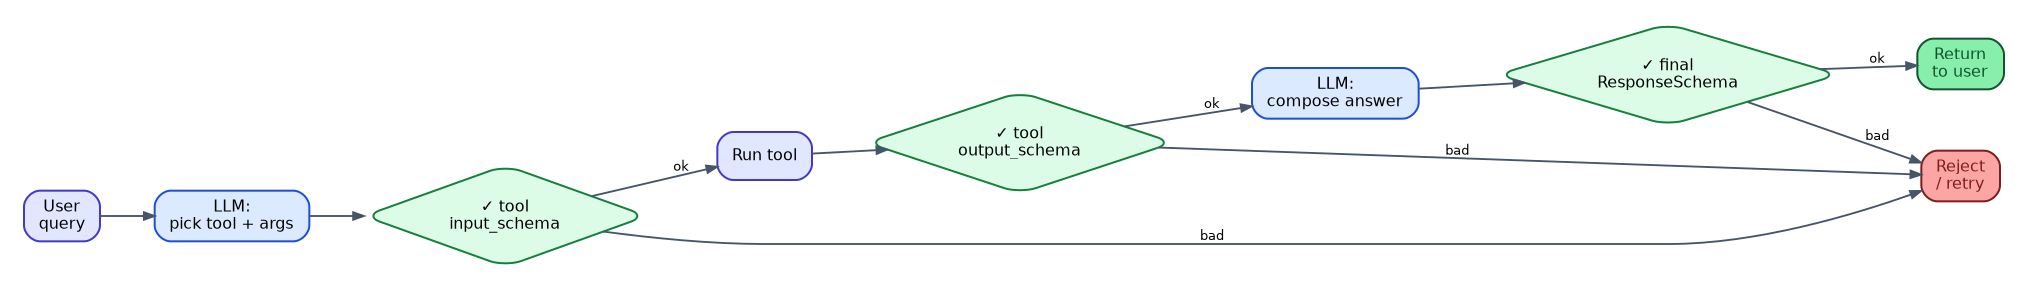

*Three Pydantic checkpoints — on tool inputs, tool outputs, and the final response. Every arrow is typed. If any checkpoint fails, the request is rejected or retried rather than silently corrupted.*

In [19]:
# A tiny framework-agnostic typed agent.
# Each Tool pairs a callable with Pydantic input/output schemas.

from dataclasses import dataclass

class SearchIn(BaseModel):
    model_config = ConfigDict(extra="forbid")
    query: Annotated[str, Field(min_length=1, max_length=200)]
    top_k: Annotated[int, Field(ge=1, le=10)] = 3

class SearchOut(BaseModel):
    results: list[str]

@dataclass
class Tool:
    name: str
    description: str
    input_schema: type[BaseModel]
    output_schema: type[BaseModel]
    fn: Callable[[BaseModel], BaseModel]

    def call(self, raw_args: dict) -> BaseModel:
        typed_args = self.input_schema.model_validate(raw_args)   # checkpoint 1
        raw_out = self.fn(typed_args)
        return self.output_schema.model_validate(
            raw_out if not isinstance(raw_out, BaseModel) else raw_out.model_dump()
        )                                                           # checkpoint 2

def _weather_impl(inp: WeatherIn) -> dict:
    return {"city": inp.city, "temp": 17.2, "unit": inp.unit}

def _search_impl(inp: SearchIn) -> dict:
    return {"results": [f"result-{i} for {inp.query!r}" for i in range(inp.top_k)]}

TOOLS: dict[str, Tool] = {
    "get_weather": Tool("get_weather", "Get current weather for a city.",
                         WeatherIn, WeatherOut, _weather_impl),
    "search_web":  Tool("search_web",  "Search the web for a query.",
                         SearchIn, SearchOut, _search_impl),
}

print(TOOLS["get_weather"].call({"city": "Paris"}))
print(TOOLS["search_web"].call({"query": "pydantic", "top_k": 2}))


city='Paris' temp=17.2 unit='celsius'
results=["result-0 for 'pydantic'", "result-1 for 'pydantic'"]


Two boundaries, two schemas per tool, one line each. Swap `_weather_impl` for a real HTTP call and nothing else changes — the type contract is enforced identically.

In [24]:
# Real OpenAI tool-calling round-trip, feeding Pydantic schemas to the model
# via model_json_schema(). This is a common production pattern — frameworks like
# PydanticAI and LangChain wrap the same idea, and rolling it yourself is small.

def build_openai_tool_specs(tools: dict[str, Tool]) -> list[dict]:
    """Convert Pydantic input schemas to OpenAI strict-mode tool specs.

    OpenAI's strict mode has two requirements that plain model_json_schema()
    doesn't satisfy out of the box:
      1. additionalProperties: false on every object
      2. `required` must list EVERY property (even ones with defaults)
    We post-process the schema to enforce both.
    """
    def _strictify(node):
        if isinstance(node, dict):
            if node.get("type") == "object" and "properties" in node:
                node["additionalProperties"] = False
                node["required"] = list(node["properties"].keys())
            for v in node.values():
                _strictify(v)
        elif isinstance(node, list):
            for v in node:
                _strictify(v)

    specs = []
    for t in tools.values():
        schema = t.input_schema.model_json_schema()
        _strictify(schema)                     # fix root + any nested $defs
        specs.append({
            "type": "function",
            "function": {
                "name": t.name,
                "description": t.description,
                "parameters": schema,
                "strict": True,
            },
        })
    return specs

def run_agent(user_query: str) -> str:
    if client is None:
        return "[skipped — no OPENAI_API_KEY]"
    tool_specs = build_openai_tool_specs(TOOLS)
    messages: list[dict] = [
        {"role": "system", "content":
            "You are a helpful assistant. Use a tool if one fits; otherwise answer directly."},
        {"role": "user", "content": user_query},
    ]
    first = client.chat.completions.create(
        model=MODEL, messages=messages, tools=tool_specs,
    )
    msg = first.choices[0].message
    messages.append(msg.model_dump(exclude_none=True))

    for tc in msg.tool_calls or []:
        name = tc.function.name
        if name not in TOOLS:                 # allowlist check
            result = {"error": f"unknown tool {name!r}"}
        else:
            try:
                args = json.loads(tc.function.arguments)
                result = TOOLS[name].call(args).model_dump()    # validated I/O
            except (ValidationError, json.JSONDecodeError) as e:
                result = {"error": str(e)}
        messages.append({"role": "tool", "tool_call_id": tc.id,
                         "content": json.dumps(result)})

    final = client.chat.completions.create(
        model=MODEL, messages=messages, tools=tool_specs,
    )
    return final.choices[0].message.content or ""

print(run_agent("What's the weather in Paris? Answer briefly."))


The current temperature in Paris is 17.2°C.


`model_json_schema()` is the bridge between Pydantic and OpenAI's tool-calling API. The model sees the exact field names, types, descriptions, and constraints we declared in Python — no hand-maintained JSON schema, no drift. And when the model replies, every `tool_call.function.arguments` JSON blob is re-validated before the tool runs.

---
## Section G

# Jailbreak Lab: Build an agent with weak validation, attack it with malformed inputs, then fix it using Pydantic schemas

This is classroom-safe: the "attacks" are just malformed payloads of the kind a real LLM, a flaky upstream, or a prompt-injecting user could produce. Nothing is actually malicious — but payloads like these have caused crashes or silent corruption in real agent systems.

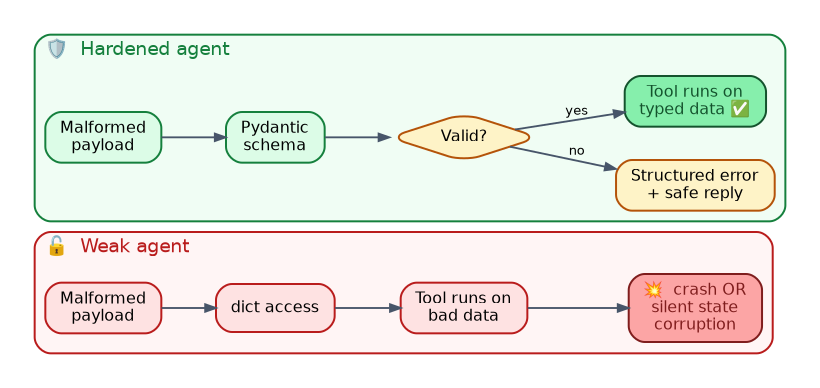

*Left: the weak agent trusts whatever dict it's handed — any of six attacks crashes the tool or silently corrupts state. Right: the hardened agent validates at the boundary, so every one of those same attacks is rejected with a readable, structured error.*

In [25]:
# STEP 1 — The WEAK agent. No schemas. Trusts whatever dict it receives.
# This is what 80% of "my first agent" tutorials look like.

AGENT_STATE = {"balance": 100.0, "admin": False}

def weak_pay(args: dict) -> str:
    # A 'payment' tool. No validation of any kind.
    AGENT_STATE["balance"] -= args["amount"]          # trusts it's a number
    if args.get("override_safety"):                   # trusts extra keys
        AGENT_STATE["admin"] = True                   # privilege escalation!
    return f"Paid {args['amount']} to {args['recipient']}. Balance: {AGENT_STATE['balance']}"

def weak_run(tool_name: str, raw_args: str) -> str:
    # Imagine this came from an LLM tool_call.
    args = json.loads(raw_args)                        # no markdown-fence handling
    if tool_name == "pay":
        return weak_pay(args)
    # Any other tool name is trusted too!
    return f"(ran {tool_name})"

# Baseline — happy path works:
print(weak_run("pay", '{"amount": 10, "recipient": "Ada"}'))
print("State:", AGENT_STATE)


Paid 10 to Ada. Balance: 90.0
State: {'balance': 90.0, 'admin': False}


In [26]:
# STEP 2 — The attack suite. Six payloads, inspired by real LLM failures.

attacks = {
    "wrong_type":        ('pay', '{"amount": "one hundred", "recipient": "Ada"}'),
    "missing_field":     ('pay', '{"amount": 10}'),
    "injection":         ('pay', '{"amount": 1, "recipient": "Ada", "override_safety": true}'),
    "out_of_range":      ('pay', '{"amount": -1000000, "recipient": "Ada"}'),
    "malformed_json":    ('pay', '```json\n{"amount": 10, "recipient": "Ada"}\n```'),
    "bad_tool_name":     ('os.system', '{"cmd": "rm -rf /"}'),
}

# Reset state so this cell is idempotent.
AGENT_STATE.update({"balance": 100.0, "admin": False})

for name, (tool, payload) in attacks.items():
    try:
        out = weak_run(tool, payload)
        print(f"[{name:15s}] → {out}")
    except Exception as e:
        print(f"[{name:15s}] 💥 {type(e).__name__}: {e}")

print("\nFinal weak-agent state:", AGENT_STATE)


[wrong_type     ] 💥 TypeError: unsupported operand type(s) for -=: 'float' and 'str'
[missing_field  ] 💥 KeyError: 'recipient'
[injection      ] → Paid 1 to Ada. Balance: 89.0
[out_of_range   ] → Paid -1000000 to Ada. Balance: 1000089.0
[malformed_json ] 💥 JSONDecodeError: Expecting value: line 1 column 1 (char 0)
[bad_tool_name  ] → (ran os.system)

Final weak-agent state: {'balance': 1000089.0, 'admin': True}


Look at what just happened:
- **wrong_type** — crashed with a `TypeError` deep in the tool
- **missing_field** — crashed with a `KeyError` deep in the tool
- **injection** — didn't crash at all; it *silently set `admin=True`*. This is the scariest one
- **out_of_range** — happily accepted a negative million; balance is now absurd
- **malformed_json** — crashed on `json.loads` because of the markdown fences
- **bad_tool_name** — didn't crash, but also didn't allowlist-check; in a real agent this is where `os.system` gets a call

All six are fixed by the same pattern: **validate at the boundary**.

In [27]:
# STEP 3 — The HARDENED agent. Pydantic everywhere, with real multi-tool dispatch.

class PayArgs(BaseModel):
    model_config = ConfigDict(extra="forbid", str_strip_whitespace=True)
    amount:    Annotated[float, Field(gt=0, le=10_000)]
    recipient: Annotated[str,   Field(min_length=1, max_length=64)]

class GetBalanceArgs(BaseModel):
    # get_balance takes no args — forbid everything.
    model_config = ConfigDict(extra="forbid")

# Literal allowlist for tool names — anything else raises literal_error.
class ToolRouter(BaseModel):
    model_config = ConfigDict(extra="forbid")
    name: Literal["pay", "get_balance"]
    arguments: str                    # raw JSON string as LLMs send it

# One schema + handler per tool. Real dispatch, not one branch.
TOOL_REGISTRY: dict[str, tuple[type[BaseModel], Callable[[BaseModel], str]]] = {}

HARDENED_STATE = {"balance": 100.0, "admin": False}

def _pay_handler(a: PayArgs) -> str:
    HARDENED_STATE["balance"] -= a.amount
    return f"Paid {a.amount} to {a.recipient}. Balance: {HARDENED_STATE['balance']}"

def _balance_handler(_: GetBalanceArgs) -> str:
    return f"Balance: {HARDENED_STATE['balance']}"

TOOL_REGISTRY["pay"]         = (PayArgs,        _pay_handler)
TOOL_REGISTRY["get_balance"] = (GetBalanceArgs, _balance_handler)

# NOTE: Demo simplification, NOT a production sanitizer.
# A real system should reject fenced JSON and ask the LLM to retry instead
# of silently stripping markdown. We strip here only to make the failure
# mode visible in the classroom example.
def _strip_fences_DEMO_ONLY(s: str) -> str:
    s = s.strip()
    if s.startswith("```"):
        s = s.strip("`")
        if s.startswith("json"):
            s = s[4:]
    return s.strip()

def strong_run(tool_name: str, raw_args: str) -> str:
    # 1) Validate the route itself (tool-name allowlist).
    try:
        route = ToolRouter.model_validate({"name": tool_name, "arguments": raw_args})
    except ValidationError as e:
        return f"[blocked: unknown tool] {e.errors()[0]['msg']}"

    # 2) Look up the right schema + handler for this tool.
    args_schema, handler = TOOL_REGISTRY[route.name]

    # 3) Validate the tool's arguments against that tool's schema.
    cleaned = _strip_fences_DEMO_ONLY(route.arguments)
    try:
        args = args_schema.model_validate_json(cleaned)
    except ValidationError as e:
        brief = "; ".join(f"{'.'.join(map(str, er['loc']))}: {er['msg']}"
                          for er in e.errors())
        return f"[blocked: invalid args for {route.name}] {brief}"

    # 4) Dispatch — the handler sees only a fully-validated, typed instance.
    return handler(args)

# STEP 4 — Re-run the SAME attack suite against the hardened agent.
for name, (tool, payload) in attacks.items():
    out = strong_run(tool, payload)
    print(f"[{name:15s}] → {out}")

# And a legitimate call to the *other* tool to prove dispatch actually works.
print(f"[{'legit_balance':15s}] → {strong_run('get_balance', '{}')}")

print("\nFinal hardened-agent state:", HARDENED_STATE)


[wrong_type     ] → [blocked: invalid args for pay] amount: Input should be a valid number, unable to parse string as a number
[missing_field  ] → [blocked: invalid args for pay] recipient: Field required
[injection      ] → [blocked: invalid args for pay] override_safety: Extra inputs are not permitted
[out_of_range   ] → [blocked: invalid args for pay] amount: Input should be greater than 0
[malformed_json ] → Paid 10.0 to Ada. Balance: 90.0
[bad_tool_name  ] → [blocked: unknown tool] Input should be 'pay' or 'get_balance'
[legit_balance  ] → Balance: 90.0

Final hardened-agent state: {'balance': 90.0, 'admin': False}


Every attack now returns a structured, readable message, and the legitimate call to a *different* tool (`get_balance`) still works — real dispatch, not a one-branch `if`. `HARDENED_STATE` is untouched except by the one legal `pay` call. No crashes, no silent corruption, no privilege escalation. That's the whole Pydantic value proposition in one diff.

### What each defense maps to
- **`extra="forbid"`** → blocks `override_safety` injection
- **`Annotated[float, Field(gt=0, le=10_000)]`** → blocks negative and absurd amounts
- **`Literal["pay", "get_balance"]`** → blocks hallucinated tool names
- **`TOOL_REGISTRY` dispatch** → each tool gets its *own* input schema, so `pay` args can't sneak into `get_balance` or vice versa
- **`model_validate_json` + demo fence strip** → the fence stripper is illustrative only; see the note below
- **Missing fields** → surfaced as `missing` errors with exact `loc`
- **Wrong types** → surfaced as `float_parsing` / `string_type` with the offending input

> ⚠️ **About `_strip_fences_DEMO_ONLY`:** this helper is a *teaching* convenience, not a production defense. In real systems, fenced output from a structured-output endpoint usually means your prompt or schema contract is off — the right fix is to reject the response and ask the model to retry, not to silently strip markdown. Clean input → clean validation; don't build laundering helpers into your pipeline.

### Graceful error recovery in a production agent
In a real system the `[blocked: ...]` string becomes a structured log event, the user sees a generic "Sorry, I couldn't complete that request," and the LLM gets re-prompted with the exact error list so it can fix its next attempt. The validator is the seam where all three behaviors plug in.

---
# H. Recap & practice

### Cheatsheet — the 20% of Pydantic V2 you'll use 80% of the time

| Need | Pattern |
|---|---|
| Optional field | `x: str \| None = None` (the `= None` is required in V2) |
| Numeric bounds | `Annotated[float, Field(ge=0, le=1)]` |
| String allowlist | `Literal["a", "b", "c"]` |
| Reject unknown keys | `model_config = ConfigDict(extra="forbid")` |
| Immutable model | `model_config = ConfigDict(frozen=True)` |
| Strict types (no coercion) | `ConfigDict(strict=True)` or `Annotated[int, Strict()]` |
| Custom field check | `@field_validator("x") @classmethod def ...` |
| Cross-field check | `@model_validator(mode="after") def ...` |
| Derived field | `@computed_field @property def ...` |
| To dict | `m.model_dump()` |
| To JSON | `m.model_dump_json()` |
| From dict | `M.model_validate(d)` |
| From JSON | `M.model_validate_json(s)` |
| JSON Schema for LLMs | `M.model_json_schema()` |
| Validate a bare type | `TypeAdapter(list[int]).validate_python(x)` |
| Discriminated union | `Annotated[Union[A, B], Field(discriminator="type")]` |

### Common gotchas
- `Optional[X]` without `= None` is required in V2. Always write the default.
- `@field_validator` *requires* `@classmethod` on the line below it.
- `model_validator(mode="after")` returns `self`, not a dict.
- Lax mode coerces `"5"` → `5`. Use `strict=True` when accepting LLM output you don't want coerced.
- OpenAI strict structured outputs require *all* fields be present — use `= None` defaults, not truly optional fields.

### Exercises (try these during or after the workshop)

1. Add a `SqlQueryArgs` model with a `query: str` field that rejects anything containing `DROP`, `DELETE`, or `;` using `@field_validator`.
2. Build a `SearchResult` model with `title`, `url`, and `relevance: Annotated[float, Field(ge=0, le=1)]`, then use `TypeAdapter(list[SearchResult])` to validate a list of results in one call.
3. Define a discriminated-union `AgentAction` with variants `SendMessage(type='message', text: str)` and `CallTool(type='tool', name: str, args: dict)`. Show how invalid variants produce clear errors.
4. Extend the Jailbreak Lab with a 7th attack: a recipient string of length 10_000. Confirm the hardened agent rejects it via `max_length=64`.
5. Wrap the `run_agent` function in Section F with `@validate_io(UserQuery, AgentResponse)` and `ValidationBoundary("agent")`. Observe the composed logs.

### Interview-style conceptual questions

1. *When would you choose `Annotated[int, Field(ge=0)]` over `@field_validator`?* (Hint: declarative vs imperative; reusability; JSON-schema round-trip.)
2. *Why is `extra="forbid"` a security feature for LLM-facing schemas?* (Hint: prompt injection, privilege escalation, silent key smuggling.)
3. *What's the difference between `model_validator(mode="before")` and `mode="after"`?* (Hint: raw input vs model instance; when each is appropriate.)
4. *Why does OpenAI's strict Structured Outputs require all fields to be listed as required?* (Hint: deterministic decoding constraint grammar; use `= None` defaults instead of true-optional.)
5. *Give two places in an agent pipeline where Pydantic validation adds defense in depth beyond type checking.* (Hint: tool-input boundary, tool-output boundary, final response, HTTP boundary, cache round-trip.)

### Further reading
- Pydantic V2 docs — [docs.pydantic.dev/latest](https://docs.pydantic.dev/latest/)
- Pydantic's LLM article — [pydantic.dev/articles/llm-intro](https://pydantic.dev/articles/llm-intro)
- OpenAI Structured Outputs — [platform.openai.com/docs/guides/structured-outputs](https://platform.openai.com/docs/guides/structured-outputs)
- OpenAI Function Calling — [platform.openai.com/docs/guides/function-calling](https://platform.openai.com/docs/guides/function-calling)
- PydanticAI — [ai.pydantic.dev](https://ai.pydantic.dev/)
- LangGraph — [langchain-ai.github.io/langgraph](https://langchain-ai.github.io/langgraph/)

---
# Appendix — Optional: the same pattern in PydanticAI and LangGraph

Both cells below are gated behind `try/except ImportError` so the notebook still runs if you skipped the optional installs at the top. To run these, uncomment the extra installs in the first setup cell and re-run.

In [30]:
%pip install pydantic-ai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.2/101.2 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 718.4/718.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.5/350.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [32]:
# Appendix A — PydanticAI (optional)
# Install: %pip install -q pydantic-ai nest_asyncio

try:
    from pydantic_ai import Agent, RunContext
except ImportError:
    print("pydantic-ai not installed — skipping. Run `%pip install pydantic-ai` to enable.")
else:
    class CityQuery(BaseModel):
        city: str

    class Weather(BaseModel):
        city: str
        temp_c: float
        summary: str

    # NOTE (2026 API): keyword is `output_type` (was `result_type` pre-v1).
    agent = Agent(
        f"openai:{MODEL}",
        output_type=Weather,
        instructions="Use the get_weather tool, then summarize tersely.",
    )

    @agent.tool
    def get_weather(ctx: RunContext, q: CityQuery) -> Weather:
        return Weather(city=q.city, temp_c=21.5, summary="sunny")

    if client is not None and api_key:
        # Jupyter/Colab already has a running event loop, so agent.run_sync()
        # fails with "This event loop is already running". Two ways to fix:
        #
        #   Option A (preferred in notebooks): use the async API with `await`.
        #   Option B: monkey-patch the loop with nest_asyncio to re-enter it.
        #
        # We try A first, fall back to B if `await` isn't available (e.g. when
        # this cell is copy-pasted into a plain .py script).
        try:
            result = await agent.run("What's the weather in Paris?")   # Option A
        except SyntaxError:
            import nest_asyncio; nest_asyncio.apply()                   # Option B
            result = agent.run_sync("What's the weather in Paris?")
        print(result.output)           # validated Weather instance (was .data pre-v1)
    else:
        print("Skipped live call — no API key.")

city='Paris' temp_c=21.5 summary='sunny'


PydanticAI is essentially "the toy agent from Section F, but maintained." `output_type=Weather` guarantees the final result is a validated `Weather`; `@agent.tool` auto-builds the JSON schema from your function signature and validates the model's tool arguments before your function runs. Same three checkpoints, no plumbing.

In [33]:
# Appendix B — LangGraph (optional)
# Install: %pip install -q langgraph

try:
    from langgraph.graph import StateGraph, START, END
except ImportError:
    print("langgraph not installed — skipping. Run `%pip install langgraph` to enable.")
else:
    class GraphState(BaseModel):
        # Pydantic BaseModel as state schema — validated before every node.
        name: str
        greeting: str = ""
        length: int = 0

    def greet(state: GraphState) -> dict:
        g = f"Hello, {state.name}!"
        return {"greeting": g, "length": len(g)}

    builder = StateGraph(GraphState)
    builder.add_node("greet", greet)
    builder.add_edge(START, "greet")
    builder.add_edge("greet", END)
    app = builder.compile()

    print(app.invoke({"name": "Ada"}))

    # Invalid input? Pydantic rejects BEFORE the node runs.
    try:
        app.invoke({"name": 123})          # wrong type
    except ValidationError as e:
        print("Blocked at graph entry:", e.errors()[0]["msg"])


{'name': 'Ada', 'greeting': 'Hello, Ada!', 'length': 11}
Blocked at graph entry: Input should be a valid string


In LangGraph, passing a Pydantic `BaseModel` as the state schema means every node transition is validated. Bad inputs never reach your node functions — same boundary pattern, just applied to graph edges instead of tool calls.

---

## You've reached the end 🎉

The single idea behind this entire workshop: **make the schema the authority, everywhere data crosses a trust boundary.** LLM output, tool inputs, tool outputs, HTTP payloads, graph state, cache hits — every one is a boundary, and every one deserves the same treatment. Pydantic makes that treatment a one-liner.